In [1]:
# ==============================
# Import Required Libraries
# ==============================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# ==============================
# Load the Dataset
# ==============================

# Load the Titanic dataset
df = pd.read_csv("raw_data.csv")

# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,Passenger 1,male,20.3,0,2,TKT00001,186.46,D33,S
1,2,1,1,Passenger 2,female,18.3,0,2,TKT00002,53.72,A10,Q
2,3,1,3,Passenger 3,female,23.0,1,2,TKT00003,108.54,E46,S
3,4,0,2,Passenger 4,male,9.1,2,1,TKT00004,152.91,NaN,S
4,5,1,2,Passenger 5,female,7.2,2,2,TKT00005,52.11,NaN,S


In [7]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          799 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        632 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             92
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          259
Embarked         0
dtype: int64

In [8]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop('Cabin', axis=1, inplace=True)

In [9]:
df.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [10]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,2,1,20.3,0,2,186.46,2
1,1,1,0,18.3,0,2,53.72,1
2,1,3,0,23.0,1,2,108.54,2
3,0,2,1,9.1,2,1,152.91,2
4,1,2,0,7.2,2,2,52.11,2


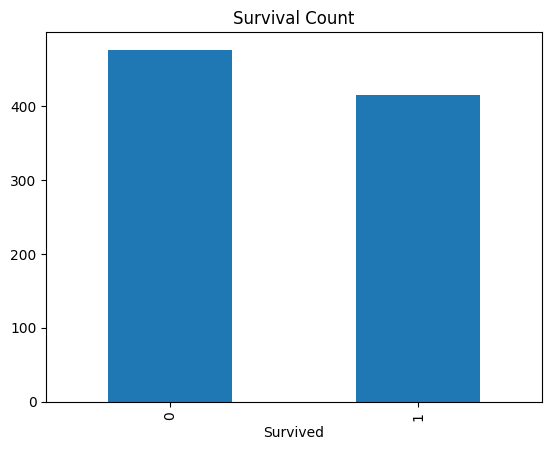

In [11]:
import matplotlib.pyplot as plt

df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.show()

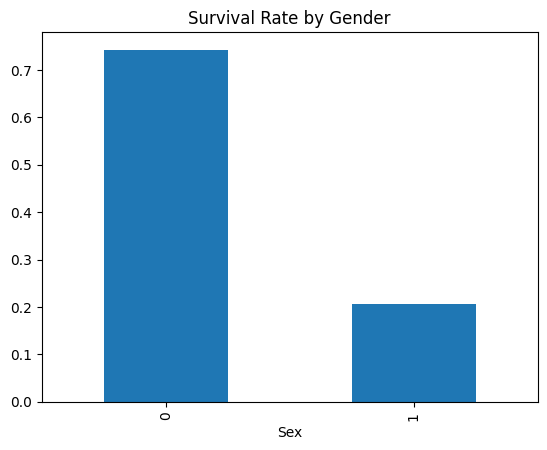

In [12]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title("Survival Rate by Gender")
plt.show()

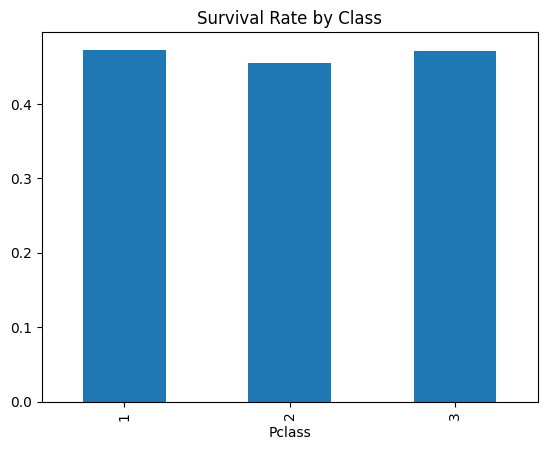

In [13]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title("Survival Rate by Class")
plt.show()

In [14]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [16]:
y_pred = model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7653631284916201

Confusion Matrix:
 [[76 17]
 [25 61]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78        93
           1       0.78      0.71      0.74        86

    accuracy                           0.77       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.77      0.76       179



In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
1,Sex,0.269058
5,Fare,0.257391
2,Age,0.251953
3,SibSp,0.073508
6,Embarked,0.051751
4,Parch,0.049845
0,Pclass,0.046494


In [20]:
df.to_csv("cleaned_titanic.csv", index=False)
print("Cleaned dataset saved!")

Cleaned dataset saved!


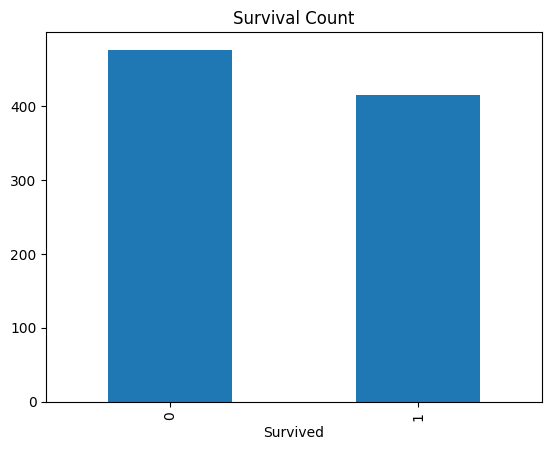

In [21]:
plt.figure()
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")

plt.savefig("survival_count.png")
plt.show()

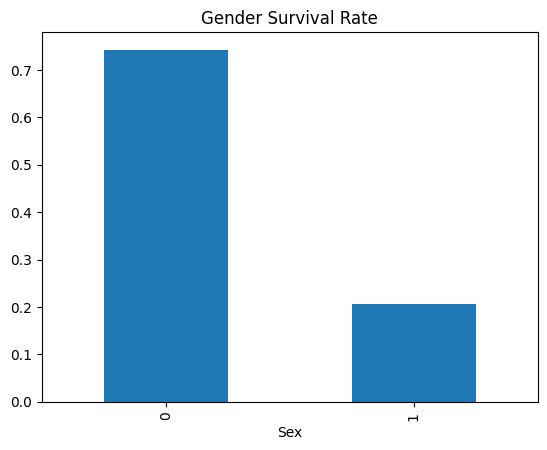

In [22]:
plt.figure()
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title("Gender Survival Rate")

plt.savefig("gender_survival.png")
plt.show()

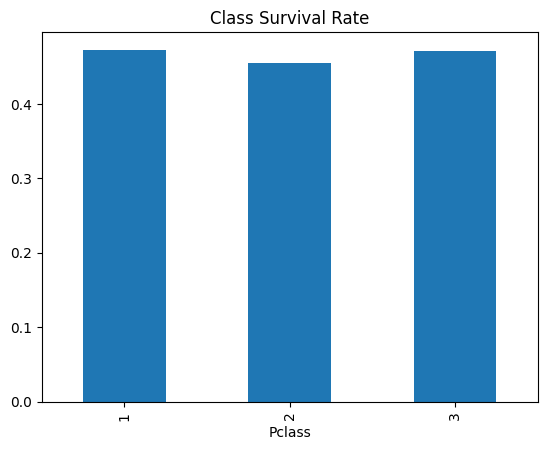

In [23]:
plt.figure()
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title("Class Survival Rate")

plt.savefig("class_survival.png")
plt.show()